In [1]:
import pandas as pd
import os 

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
 # Load the dataset
test = "test_5"
df = pd.read_csv('./data/'+test+'/robot_log.csv', delimiter=';')
df['Path'][0]

'C:\\Users\\ericu\\Desktop\\Windows_Roversim\\Roversim_logging\\ZigZag_Driving\\IMG\\robocam_2025_04_05_17_54_29_119.jpg'

In [3]:

image_dir = 'data/'+test+'/IMG/'
#df['Path'] = df['Path'].apply(lambda p: os.path.basename(p)).replace('\\', '/')
#df['Path'] = df['Path'].str.replace(r'^C:\\Users\\Chris SB\\Downloads\\IMG\\', '', regex=True)

df['Path'] = df['Path'].str.replace(r"^C:\\Users\\ericu\\Desktop\\Windows_Roversim\\Roversim_logging\\ZigZag_Driving\\IMG\\", '', regex=True)

#df['Path'] = df['Path'].str.replace(r"^C:\\Mark's Python files\\ME5920\\HW3_Gardocki\\IMG\\", '', regex=True)


## Update the Path column to have full paths
df['Path'] = df['Path'].apply(lambda x: os.path.join(image_dir, x))
df = df.sample(frac=1).reset_index(drop=True)


In [4]:
img_path = df['Path'][20]
img_path

'data/test_5/IMG/robocam_2025_04_05_17_56_20_928.jpg'

data/test_5/IMG/robocam_2025_04_05_17_56_20_928.jpg
15.0
0.0


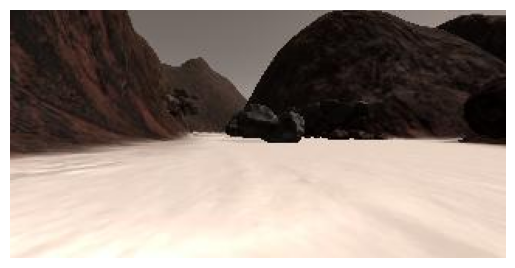

In [5]:
img_path = df['Path'][20]
print(img_path)
print(df['SteerAngle'][20])
print(df['Throttle'][20])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

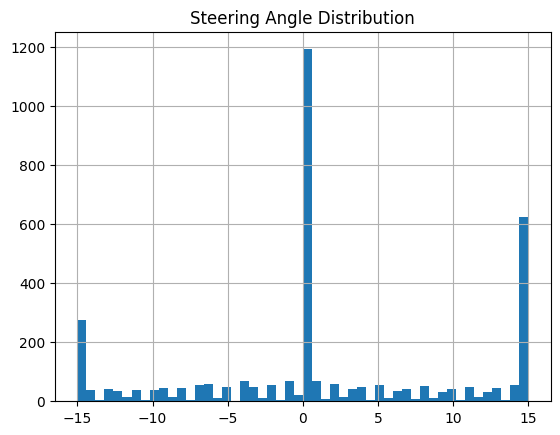

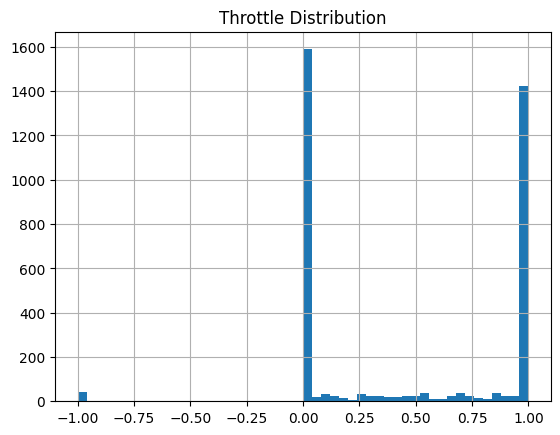

In [6]:
df['SteerAngle'].hist(bins=50)
plt.title('Steering Angle Distribution')
plt.show()

df['Throttle'].hist(bins=50)
plt.title('Throttle Distribution')
plt.show()

In [7]:
 # Select relevant columns
df = df[['Path', 'SteerAngle', 'Throttle']]


In [8]:
# Set the overrepresented steering angle and desired count
oversampled_angle = 0.0
desired_count = 400

# Separate the DataFrame into the oversampled group and the rest
df_oversampled = df[df['SteerAngle'] == oversampled_angle]
df_rest = df[df['SteerAngle'] != oversampled_angle]

# Check current number of oversampled instances (should be ~1200)
print("Oversampled count before:", len(df_oversampled))

# Downsample the oversampled group to the desired count
df_oversampled_downsampled = df_oversampled.sample(n=desired_count, random_state=42)

# Combine the downsampled group with the rest of the data
df_downsampled = pd.concat([df_oversampled_downsampled, df_rest]).reset_index(drop=True)

print("Total count after downsampling:", len(df_downsampled))

Oversampled count before: 1169
Total count after downsampling: 2829


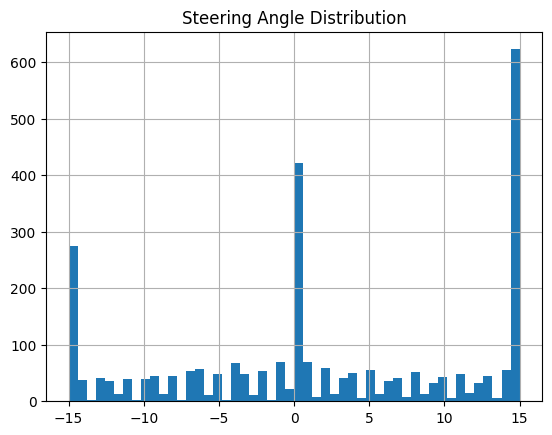

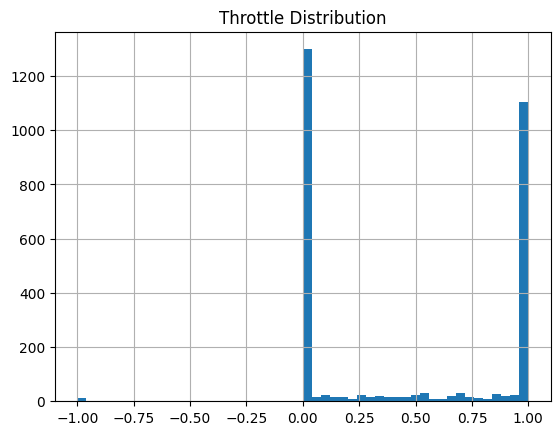

In [9]:
df = df_downsampled
df['SteerAngle'].hist(bins=50)
plt.title('Steering Angle Distribution')
plt.show()

df['Throttle'].hist(bins=50)
plt.title('Throttle Distribution')
plt.show()

In [10]:
  import numpy as np
  import cv2
  from tensorflow.keras.utils import Sequence

import random

def augment_image(image):
    # Random brightness (in HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    ratio = 0.4 + np.random.uniform()  # random brightness factor
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * ratio, 0, 255)
    image = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # Random horizontal flip
    if random.random() < 0.5:
        image = cv2.flip(image, 1)  # flip image
        flipped = True
    else:
        flipped = False

    return image, flipped


  class DataGenerator(Sequence):
      def __init__(self, dataframe, batch_size=32, dim=(66, 200), shuffle=True, augment=False):
          self.df = dataframe
          self.batch_size = batch_size
          self.dim = dim
          self.shuffle = shuffle
          self.augment = augment 
          self.on_epoch_end()
          

      def __len__(self):
          return int(np.floor(len(self.df) / self.batch_size))

      def __getitem__(self, index):
          indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
          batch_data = self.df.iloc[indexes]
          X, y = self.__data_generation(batch_data)
          return X, y

      def on_epoch_end(self):
          self.indexes = np.arange(len(self.df))
          if self.shuffle:
              np.random.shuffle(self.indexes)

      def __data_generation(self, batch_data):
          images = []
          steer_angles = []
          throttles = []
          for _, row in batch_data.iterrows():
              img = cv2.imread(row['Path'])
              img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              img = cv2.resize(img, (self.dim[1], self.dim[0]))  # ✅ width first, then height

            
              #if self.augment:
                #img, flipped = augment_image(img)
                #if flipped:
                # If we flipped the image, we should flip the steering angle too
                    #steer = -row['SteerAngle']
               # else:
                   # steer = row['SteerAngle']
              #else:
                #steer = row['SteerAngle']
            
              images.append(img)
              steer_angles.append(row['SteerAngle']) #append(steer)
              throttles.append(row['Throttle'])
              

          X = np.array(images, dtype=np.float32) / 255.0  # Normalize
          y = np.array(list(zip(steer_angles, throttles)), dtype=np.float32)
          return X, y

2025-04-07 02:34:36.552504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-07 02:34:36.567080: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-07 02:34:36.572075: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-07 02:34:36.584324: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
from sklearn.model_selection import train_test_split

# Split the dataset
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [12]:
# Parameters
batch_size = 32
image_size = (66, 200)

# Generators
training_generator = DataGenerator(train_df, batch_size=batch_size, dim=image_size, augment=True)
validation_generator = DataGenerator(val_df, batch_size=batch_size, dim=image_size, augment=False)

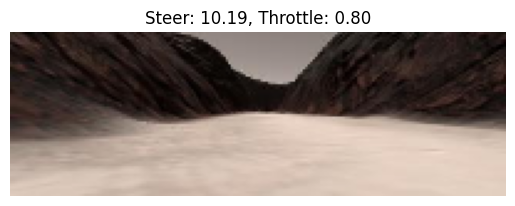

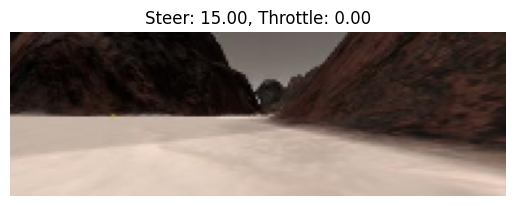

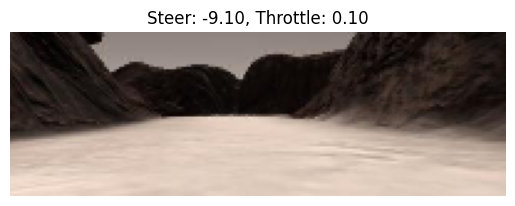

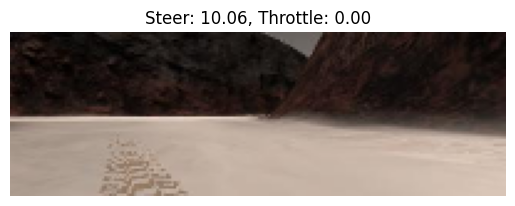

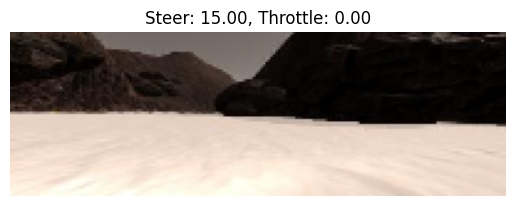

In [13]:
# Show random images from validation_generator
X_val, y_val = validation_generator.__getitem__(0)

for i in range(min(5, X_val.shape[0])):
    plt.imshow(X_val[i])
    plt.title(f"Steer: {y_val[i][0]:.2f}, Throttle: {y_val[i][1]:.2f}")
    plt.axis('off')
    plt.show()

In [14]:
X_test, y_test = training_generator.__getitem__(0)
print(X_test.shape)  # Should be (batch_size, 66, 200, 3)
print(y_test.shape)  # Should be (batch_size, 2)
print(X_test.dtype)  # Should be float32
print(y_test.dtype)  # Should be float32

(32, 66, 200, 3)
(32, 2)
float32
float32


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras import Input

# Build the model
def build_model():
    model = Sequential()

    # Normalization
    model.add(Input(shape=(66, 200, 3)))  # ✅ Explicit input layer
    #model.add(Lambda(lambda x: x / 255.0))  # No need for input_shape here anymore

    # Convolutional layers
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='relu', input_shape=(66, 200, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    

    # Fully connected layers
    model.add(Flatten())
    model.add(Dense(1164, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(50, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(10, activation='relu'))
    model.add(Dropout(0.3))
    
    #model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='relu'))
    #model.add(BatchNormalization())
    

    # Output layer: 2 values (SteerAngle, Throttle)
    model.add(Dense(2))  # Linear activation by default

    return model

    # ----------------------------
# 2. Define custom loss function
# ----------------------------
def custom_loss(y_true, y_pred):
    steer_true, throttle_true = y_true[:, 0], y_true[:, 1]
    steer_pred, throttle_pred = y_pred[:, 0], y_pred[:, 1]
    
    # Example: Weighted MSE
    steer_loss = tf.reduce_mean(tf.square(steer_true - steer_pred))
    throttle_loss = tf.reduce_mean(tf.square(throttle_true - throttle_pred))
    
    # Suppose we know steering angles are heavily overrepresented near 0,
    # we could weigh them differently.
    return 0.7 * steer_loss + 0.3 * throttle_loss

In [16]:
model = build_model()
model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")

/home/exouser/.conda/envs/my5920_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1743993278.819801  261838 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1743993278.892042  261838 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1743993278.892327

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor='val_loss',        # Watch the validation loss
    patience=5,                # Wait 3 epochs after last improvement
    restore_best_weights=True # Use the best model, not the last one
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=50,                 # Set a high cap
    callbacks =[lr_scheduler]
)

Epoch 1/50


/home/exouser/.conda/envs/my5920_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1743993282.841390  262019 service.cc:146] XLA service 0x732bc0002340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743993282.841427  262019 service.cc:154]   StreamExecutor device (0): GRID A100X-8C, Compute Capability 8.0
2025-04-07 02:34:42.914659: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-07 02:34:43.323656: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90800
Could not

14/70 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 50.8986

I0000 00:00:1743993291.034242  262019 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 45.4038

2025-04-07 02:34:53.276329: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_152', 176 bytes spill stores, 176 bytes spill loads



70/70 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 45.3406 - val_loss: 48.0210 - learning_rate: 0.0010
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 36.6517 - val_loss: 48.9224 - learning_rate: 0.0010
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 34.0074 - val_loss: 39.1185 - learning_rate: 0.0010
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 27.6915 - val_loss: 39.9946 - learning_rate: 0.0010
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 27.0771 - val_loss: 32.2886 - learning_rate: 0.0010
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 25.1590 - val_loss: 23.4211 - learning_rate: 0.0010
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 20.6954 - val_loss: 28.0362 - learning_rate: 0.0010
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 21.2084 - val_loss: 21.8243 - learning_rate: 0.0010
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 20.2388 - val_loss: 26.5414 - learning_rate: 0.0010
Epoch 10/50

In [18]:
"""
from tensorflow.keras.optimizers import Adam

# Re-compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5), loss='mse')

# Optional: You can reset the callbacks if needed
early_stop = EarlyStopping(patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)

model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=15,  # Just a few more
    callbacks=[lr_scheduler]
)
"""

"\nfrom tensorflow.keras.optimizers import Adam\n\n# Re-compile the model with a lower learning rate\nmodel.compile(optimizer=Adam(learning_rate=1e-5), loss='mse')\n\n# Optional: You can reset the callbacks if needed\nearly_stop = EarlyStopping(patience=3, restore_best_weights=True)\nlr_scheduler = ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)\n\nmodel.fit(\n    training_generator,\n    validation_data=validation_generator,\n    epochs=15,  # Just a few more\n    callbacks=[lr_scheduler]\n)\n"

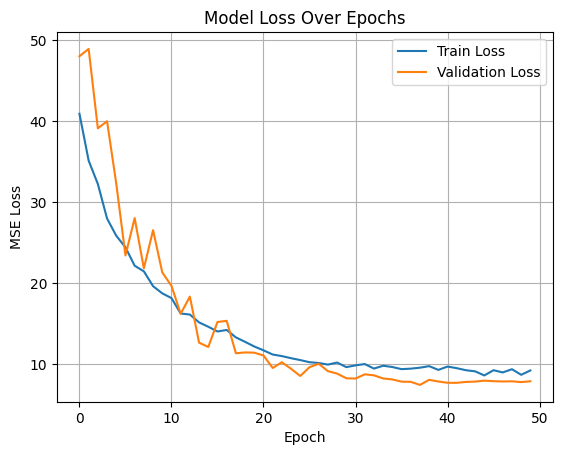

In [19]:
# Plot training & validation loss
plt.plot(model.history.history['loss'], label='Train Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
val_loss = model.evaluate(validation_generator)
print(f"Validation MSE Loss: {val_loss}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.7486
Validation MSE Loss: 7.848289966583252


In [21]:
X_sample, y_true = validation_generator.__getitem__(0)  # get one batch
y_pred = model.predict(X_sample)

# Show first prediction vs. ground truth
print("Prediction (Steer, Throttle):", y_pred[0])
print("Actual (Steer, Throttle):", y_true[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
Prediction (Steer, Throttle): [-9.445585    0.46665114]
Actual (Steer, Throttle): [-14.17232   1.     ]


In [22]:
model.save('test5model.keras')

In [23]:
# Collect all predictions and true labels
y_preds = []
y_trues = []

for i in range(len(validation_generator)):
    X_batch, y_batch = validation_generator[i]
    preds = model.predict(X_batch)
    y_preds.append(preds)
    y_trues.append(y_batch)

# Combine all batches
y_preds = np.vstack(y_preds)
y_trues = np.vstack(y_trues)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


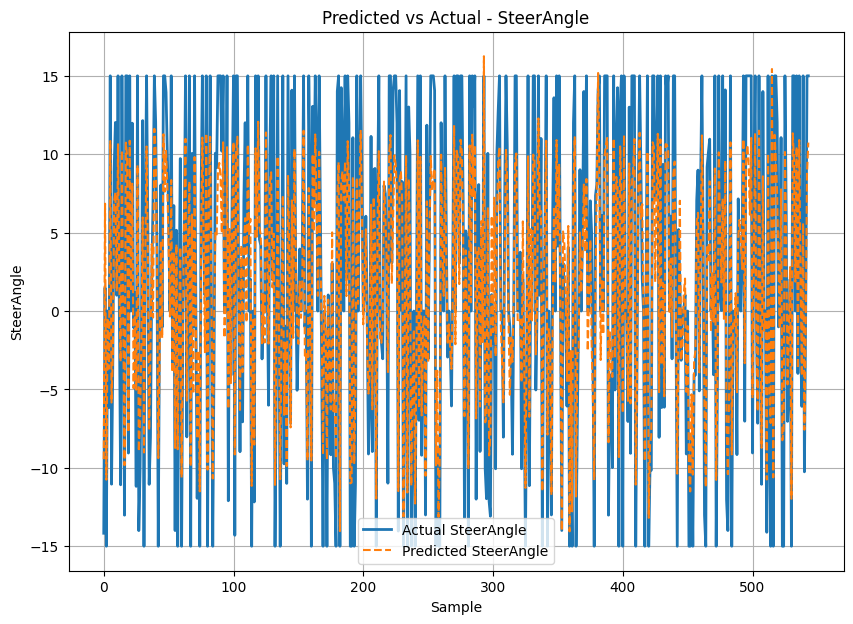

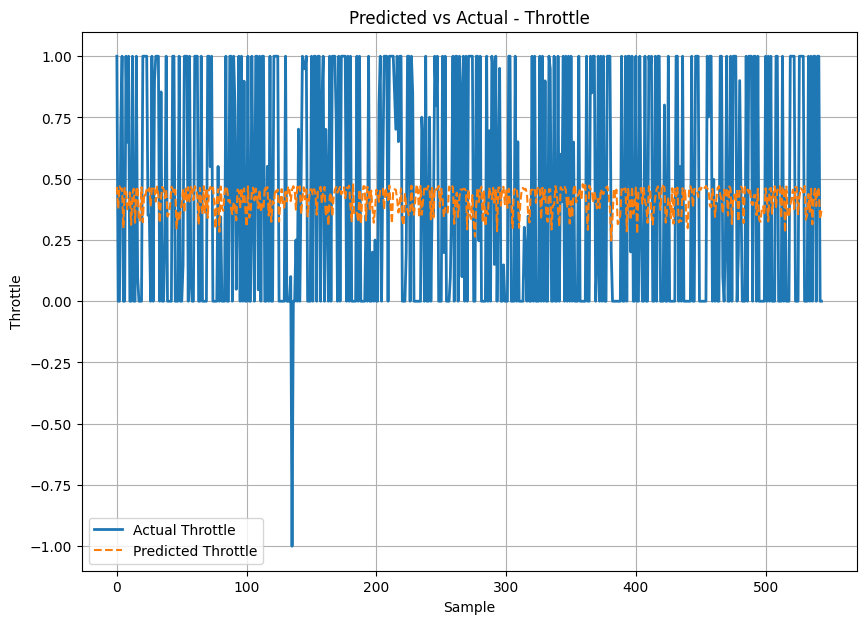

In [24]:
import matplotlib.pyplot as plt

# Plot SteerAngle
plt.figure(figsize=(10, 7))
plt.plot(y_trues[:, 0], label='Actual SteerAngle', linewidth=2)
plt.plot(y_preds[:, 0], label='Predicted SteerAngle', linestyle='--')
plt.title("Predicted vs Actual - SteerAngle")
plt.xlabel("Sample")
plt.ylabel("SteerAngle")
plt.legend()
plt.grid(True)
plt.show()

# Plot Throttle
plt.figure(figsize=(10, 7))
plt.plot(y_trues[:, 1], label='Actual Throttle', linewidth=2)
plt.plot(y_preds[:, 1], label='Predicted Throttle', linestyle='--')
plt.title("Predicted vs Actual - Throttle")
plt.xlabel("Sample")
plt.ylabel("Throttle")
plt.legend()
plt.grid(True)
plt.show()


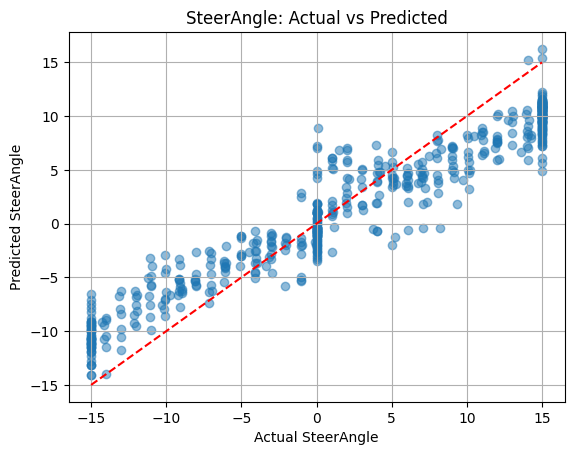

In [25]:
plt.scatter(y_trues[:, 0], y_preds[:, 0], alpha=0.5)
plt.xlabel("Actual SteerAngle")
plt.ylabel("Predicted SteerAngle")
plt.title("SteerAngle: Actual vs Predicted")
plt.grid(True)
plt.plot([-15, 15], [-15, 15], 'r--')  # Ideal line
plt.show()

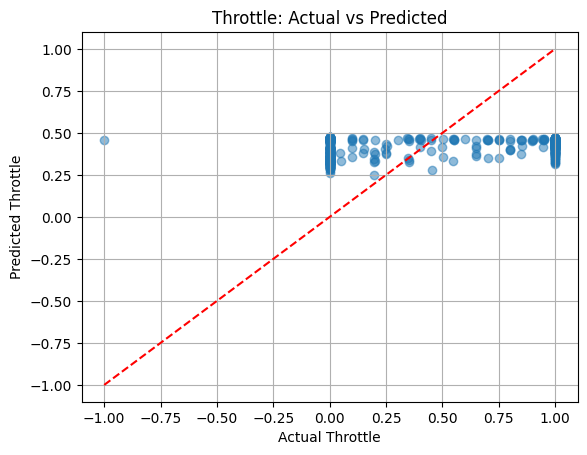

In [26]:
plt.scatter(y_trues[:, 1], y_preds[:, 1], alpha=0.5)
plt.xlabel("Actual Throttle")
plt.ylabel("Predicted Throttle")
plt.title("Throttle: Actual vs Predicted")
plt.grid(True)
plt.plot([-1, 1], [-1, 1], 'r--')  # Ideal line
plt.show()